In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error

%matplotlib inline

In [2]:
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
sample_submission = pd.read_csv("data/sample_submission.csv")

In [3]:
train.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [4]:
test.head()

,id,date,store,item
0,0,2018-01-01,1,1
1,1,2018-01-02,1,1
2,2,2018-01-03,1,1
3,3,2018-01-04,1,1
4,4,2018-01-05,1,1


In [5]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

train.info()

Train Shape: (913000, 4)
Test Shape: (45000, 4)
<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  str  
 1   store   913000 non-null  int64
 2   item    913000 non-null  int64
 3   sales   913000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 27.9 MB


In [6]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (913000, 4)
Test Shape: (45000, 4)


In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  str  
 1   store   913000 non-null  int64
 2   item    913000 non-null  int64
 3   sales   913000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 27.9 MB


In [8]:
train.isnull().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [9]:
train.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [10]:
train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])

In [11]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[us]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 27.9 MB


In [12]:
for df in [train, test]:
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek
    df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
    df["quarter"] = df["date"].dt.quarter
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

In [13]:
train.head()

,date,store,item,sales,year,month,day,dayofweek,weekofyear,quarter,is_weekend
0,2013-01-01,1,1,13,2013,1,1,1,1,1,0
1,2013-01-02,1,1,11,2013,1,2,2,1,1,0
2,2013-01-03,1,1,14,2013,1,3,3,1,1,0
3,2013-01-04,1,1,13,2013,1,4,4,1,1,0
4,2013-01-05,1,1,10,2013,1,5,5,1,1,1


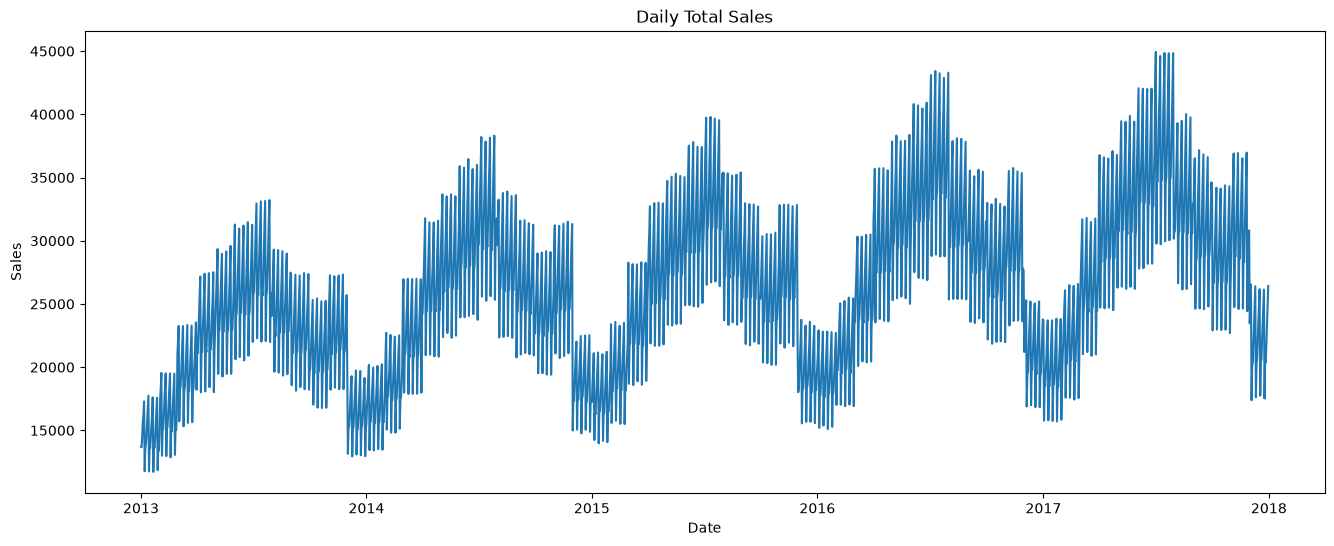

In [14]:
daily_sales = train.groupby("date")["sales"].sum()

plt.figure(figsize=(16,6))
plt.plot(daily_sales)

plt.title("Daily Total Sales")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

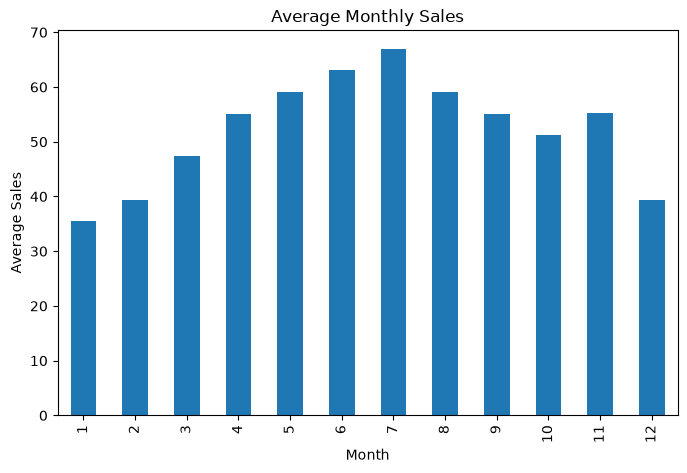

In [15]:
monthly_sales = train.groupby("month")["sales"].mean()

plt.figure(figsize=(8,5))

monthly_sales.plot(kind="bar")

plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.show()

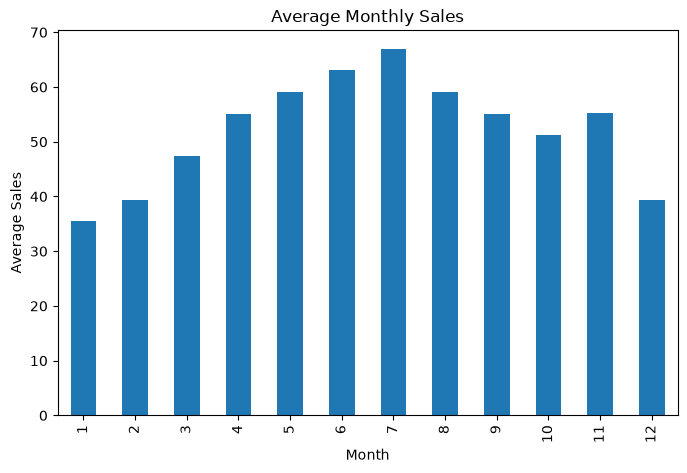

In [16]:
monthly_sales = train.groupby("month")["sales"].mean()

plt.figure(figsize=(8,5))

monthly_sales.plot(kind="bar")

plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.show()

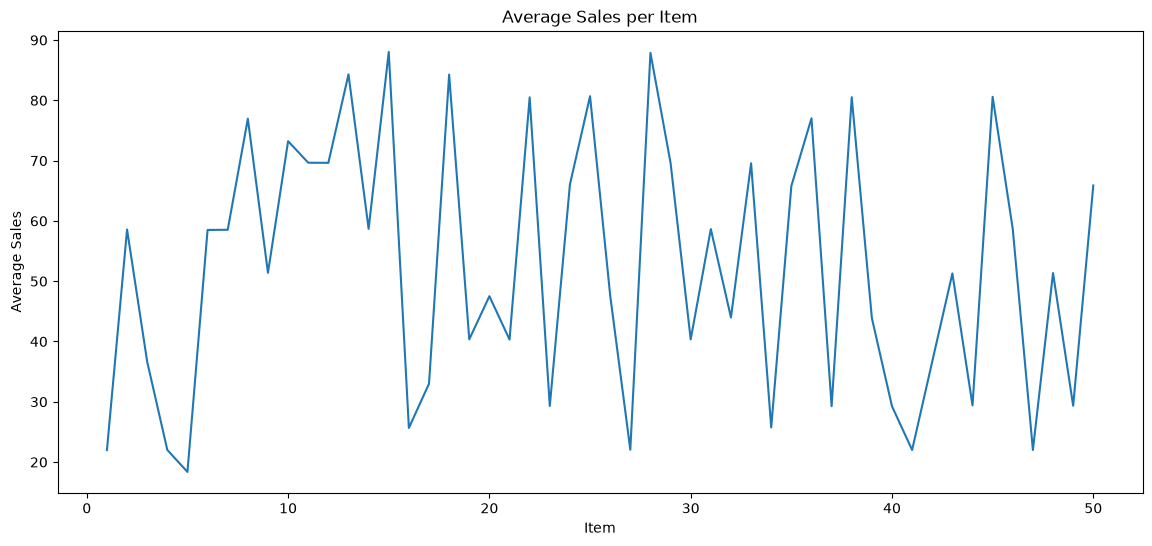

In [17]:
item_sales = train.groupby("item")["sales"].mean()

plt.figure(figsize=(14,6))

plt.plot(item_sales)

plt.title("Average Sales per Item")
plt.xlabel("Item")
plt.ylabel("Average Sales")

plt.show()

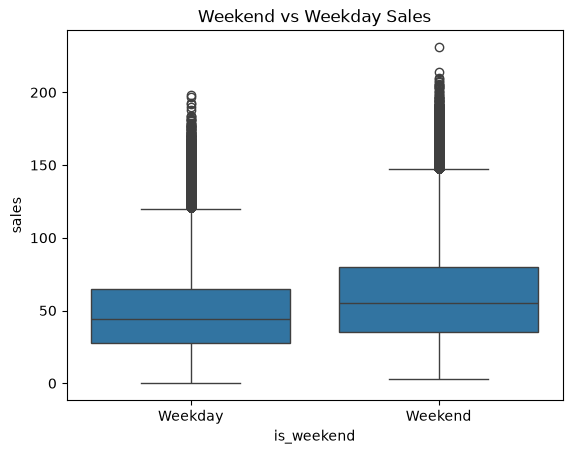

In [18]:
sns.boxplot(data=train, x="is_weekend", y="sales")

plt.title("Weekend vs Weekday Sales")

plt.xticks([0,1],["Weekday","Weekend"])

plt.show()

In [ ]:
train = train.sort_values(["store", "item", "date"])

train["lag_7"] = train.groupby(["store", "item"])["sales"].shift(7)
train["lag_14"] = train.groupby(["store", "item"])["sales"].shift(14)
train["lag_28"] = train.groupby(["store", "item"])["sales"].shift(28)

In [20]:
train.head(35)

,date,store,item,sales,year,month,day,dayofweek,weekofyear,quarter,is_weekend,lag_7,lag_14,lag_28
0,2013-01-01,1,1,13,2013,1,1,1,1,1,0,NaN,NaN,NaN
1,2013-01-02,1,1,11,2013,1,2,2,1,1,0,NaN,NaN,NaN
2,2013-01-03,1,1,14,2013,1,3,3,1,1,0,NaN,NaN,NaN
3,2013-01-04,1,1,13,2013,1,4,4,1,1,0,NaN,NaN,NaN
4,2013-01-05,1,1,10,2013,1,5,5,1,1,1,NaN,NaN,NaN
5,2013-01-06,1,1,12,2013,1,6,6,1,1,1,NaN,NaN,NaN
6,2013-01-07,1,1,10,2013,1,7,0,2,1,0,NaN,NaN,NaN
7,2013-01-08,1,1,9,2013,1,8,1,2,1,0,13.0,NaN,NaN
8,2013-01-09,1,1,12,2013,1,9,2,2,1,0,11.0,NaN,NaN
9,2013-01-10,1,1,9,2013,1,10,3,2,1,0,14.0,NaN,NaN


In [21]:
train["rolling_mean_7"] = (
    train.groupby(["store", "item"])["sales"]
         .transform(lambda x: x.shift(1).rolling(7).mean())
)

train["rolling_mean_30"] = (
    train.groupby(["store", "item"])["sales"]
         .transform(lambda x: x.shift(1).rolling(30).mean())
)

In [22]:
train.isnull().sum()

date                   0
store                  0
item                   0
sales                  0
year                   0
month                  0
day                    0
dayofweek              0
weekofyear             0
quarter                0
is_weekend             0
lag_7               3500
lag_14              7000
lag_28             14000
rolling_mean_7      3500
rolling_mean_30    15000
dtype: int64

In [23]:
train = train.dropna().reset_index(drop=True)

In [24]:
train = train.dropna().reset_index(drop=True)

In [25]:
train.isnull().sum()

date               0
store              0
item               0
sales              0
year               0
month              0
day                0
dayofweek          0
weekofyear         0
quarter            0
is_weekend         0
lag_7              0
lag_14             0
lag_28             0
rolling_mean_7     0
rolling_mean_30    0
dtype: int64

In [26]:
train_df = train[train["date"] < "2017-01-01"]
valid_df = train[train["date"] >= "2017-01-01"]

print(train_df.shape)
print(valid_df.shape)

(715500, 16)
(182500, 16)


In [27]:
features = [
    "store",
    "item",
    "year",
    "month",
    "day",
    "dayofweek",
    "weekofyear",
    "quarter",
    "is_weekend",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_30"
]

In [28]:
import lightgbm
print(lightgbm.__version__)

4.6.0


In [29]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

model.fit(
    train_df[features],
    train_df["sales"]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039802 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1241
[LightGBM] [Info] Number of data points in the train set: 715500, number of used features: 14
[LightGBM] [Info] Start training from score 51.056034


,learning_rate,0.05
,n_estimators,500
,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [30]:
import lightgbm
print(lightgbm.__version__)

4.6.0


In [31]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

model.fit(
    train_df[features],
    train_df["sales"]
)

print("Model trained successfully!")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058137 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1241
[LightGBM] [Info] Number of data points in the train set: 715500, number of used features: 14
[LightGBM] [Info] Start training from score 51.056034
Model trained successfully!


In [32]:
valid_pred = model.predict(valid_df[features])

valid_pred[:10]

array([20.19192181, 12.4279832 , 14.37747881, 14.71582924, 16.37496979,
       16.97844622, 16.94754806, 19.28644478, 12.75636474, 15.17479651])

In [33]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(valid_df["sales"], valid_pred)

print("Validation MAE:", mae)

Validation MAE: 6.09791458373166


In [34]:
import numpy as np

def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred) / denominator
    diff[denominator == 0] = 0
    return np.mean(diff) * 100

smape_score = smape(valid_df["sales"].values, valid_pred)

print(f"Validation SMAPE: {smape_score:.2f}%")

Validation SMAPE: 12.06%


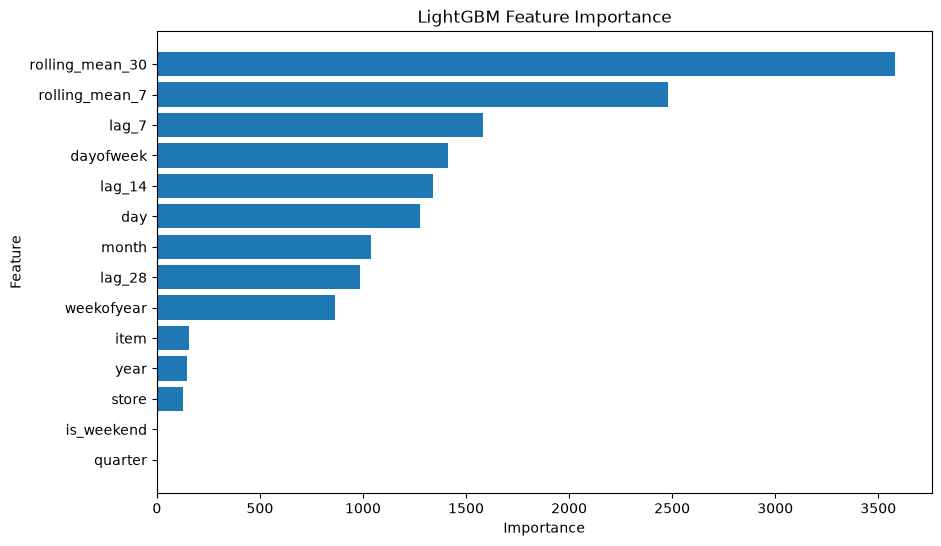

,Feature,Importance
13,rolling_mean_30,3581
12,rolling_mean_7,2478
9,lag_7,1584
5,dayofweek,1413
10,lag_14,1341
4,day,1279
3,month,1040
11,lag_28,986
6,weekofyear,863
1,item,155


In [36]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("LightGBM Feature Importance")
plt.gca().invert_yaxis()
plt.show()

importance

In [37]:
comparison = pd.DataFrame({
    "Actual": valid_df["sales"].values,
    "Predicted": valid_pred
})

comparison.head(20)

,Actual,Predicted
0,19,20.191922
1,15,12.427983
2,10,14.377479
3,16,14.715829
4,14,16.374970
5,24,16.978446
6,14,16.947548
7,20,19.286445
8,18,12.756365
9,11,15.174797


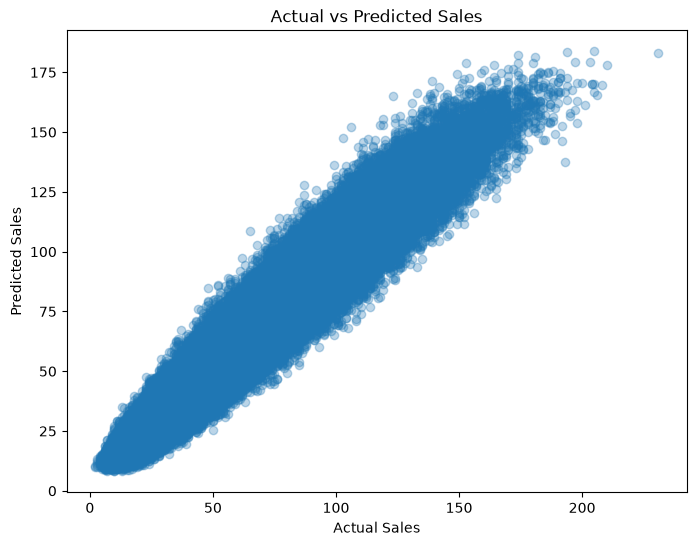

In [38]:
plt.figure(figsize=(8,6))
plt.scatter(
    comparison["Actual"],
    comparison["Predicted"],
    alpha=0.3
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [39]:
import joblib

joblib.dump(model, "lightgbm_sales_forecasting.pkl")

print("Model saved successfully!")

Model saved successfully!


In [40]:
importance.to_csv("feature_importance.csv", index=False)